# 📊 DBSCAN 실습: 식사 데이터로 이상 고객 탐지

---

# 🎯 1. 문제 정의

> “식사 데이터를 기반으로 고객 그룹을 나누고, 이상한 고객을 찾아보자”

👉 K-Means와 달리
👉 DBSCAN은 **이상치(-1)**를 자동으로 탐지한다

---

# 🧪 2. 데이터 로드

```python
import seaborn as sns
import pandas as pd

df = sns.load_dataset("tips")

# 사용할 컬럼
df = df[["total_bill", "tip", "size"]]

print(df.head())
```

---

# 🧠 컬럼 의미

| 컬럼         | 설명      |
| ---------- | ------- |
| total_bill | 총 식사 금액 |
| tip        | 팁       |
| size       | 인원 수    |

---

# ⚙️ 3. 전처리

```python
from sklearn.preprocessing import StandardScaler

X = df[["total_bill", "tip", "size"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
```

---

# 🌳 4. DBSCAN 적용

```python
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.8, min_samples=5)
df["Cluster"] = model.fit_predict(X_scaled)
```

---

# 📊 5. 시각화

```python
import matplotlib.pyplot as plt

plt.scatter(df["total_bill"], df["tip"], c=df["Cluster"])
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("DBSCAN Clustering (Outlier Detection)")
plt.show()
```

---

# 🔥 6. 결과 해석

## 📊 클러스터 의미

* **0, 1, 2 ...** → 정상 고객 그룹
* **-1** → 이상 고객 💣

---

## 🧠 예시 해석

### 🟢 Cluster 0

* 평균적인 식사 금액
* 일반적인 팁

👉 **일반 고객**

---

### 🔵 Cluster 1

* 금액 높음
* 팁 많음

👉 **고급 소비 고객**

---

### 🔴 Cluster -1 (중요🔥)

👉 특징:

* 너무 많이 쓰거나
* 너무 적게 쓰거나
* 패턴에서 벗어남

👉 의미:

> 💣 **이상 고객 (Outlier)**

---

# 😲 7. 핵심 인사이트

```text
DBSCAN은 군집을 나누는 것보다
“튀는 데이터”를 찾는 데 강하다
```

---

# 💡 8. 실전 활용

* 💳 금융 → 이상 거래 탐지
* 🛒 쇼핑 → 비정상 소비 고객
* 🔐 보안 → 해킹 패턴 탐지
* 🏥 헬스 → 이상 건강 데이터 탐지

---

# ⚠️ 9. 파라미터 중요성

```python
DBSCAN(eps=0.5)  # 너무 작음 → 군집 깨짐
DBSCAN(eps=1.5)  # 너무 큼 → 다 합쳐짐
```

👉 eps 튜닝이 핵심 🔥

---

# 🧠 핵심 흐름

```text
데이터 준비 → 스케일링 → DBSCAN → 이상치 탐지
```

---

# 🚀 한 줄 정리

> DBSCAN = “비슷한 데이터는 묶고, 이상한 데이터는 따로 분리하는 알고리즘”


In [7]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("tips")

# 사용할 컬럼
df = df[["total_bill", "tip", "size"]]

print(df.head())

   total_bill   tip  size
0       16.99  1.01     2
1       10.34  1.66     3
2       21.01  3.50     3
3       23.68  3.31     2
4       24.59  3.61     4


In [8]:
from sklearn.preprocessing import StandardScaler

X = df[["total_bill", "tip", "size"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
from sklearn.cluster import DBSCAN

model = DBSCAN(eps=0.8, min_samples=5)
df["Cluster"] = model.fit_predict(X_scaled)

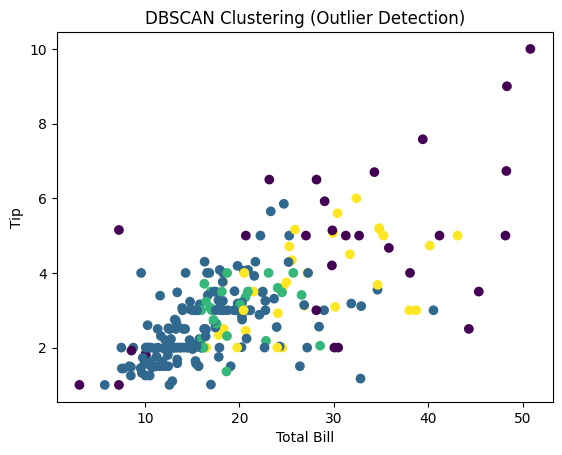

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df["total_bill"], df["tip"], c=df["Cluster"])
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("DBSCAN Clustering (Outlier Detection)")
plt.show()

In [11]:
print(df["Cluster"].value_counts())

Cluster
 0    154
 2     33
 1     29
-1     28
Name: count, dtype: int64


In [12]:
print(df.groupby("Cluster").mean(numeric_only=True))

         total_bill       tip      size
Cluster                                
-1        30.380000  4.672857  3.571429
 0        16.402338  2.549935  2.000000
 1        19.022759  2.925862  3.000000
 2        27.257879  3.733333  4.000000


# 📊 DBSCAN 결과 해석: 식사 데이터 고객 세그먼테이션

---

# 🎯 1. 전체 구조 요약

* **Cluster 0** → 소규모 / 저가 소비 고객
* **Cluster 1** → 중간 규모 / 일반 소비 고객
* **Cluster 2** → 대규모 / 고가 소비 고객
* **Cluster -1** → 이상치 고객 (Outlier) 💣

---

# 🧠 2. 군집별 상세 해석

---

## 🟢 Cluster 0 (기본 고객층)

### 📊 특징

* total_bill ≈ 16.4 (낮음)
* tip ≈ 2.55 (보통)
* size ≈ 2명

### 👉 해석

👥 **소규모 일반 고객**

* 2명 중심 식사
* 평균적인 소비 패턴
* 가장 일반적인 고객 유형

👉 ✔ **핵심 고객층 (Major Segment)**

---

## 🔵 Cluster 1 (중간 그룹)

### 📊 특징

* total_bill ≈ 19.0
* tip ≈ 2.92
* size ≈ 3명

### 👉 해석

👨‍👩‍👧 **소규모 모임 / 가족 고객**

* 인원 증가
* 소비 약간 증가

👉 ✔ **일반 소비 + 모임형 고객**

---

## 🟡 Cluster 2 (고소비 그룹)

### 📊 특징

* total_bill ≈ 27.3 (높음)
* tip ≈ 3.73 (높음)
* size ≈ 4명

### 👉 해석

🥂 **단체 + 고소비 고객**

* 인원 많음
* 소비 큼
* 팁도 큼

👉 ✔ **VIP / 단체 고객**

---

## 🔴 Cluster -1 (🔥 핵심)

### 📊 특징

* total_bill ≈ 30.38 (매우 높음)
* tip ≈ 4.67 (매우 높음)
* size ≈ 3.57 (애매)

---

### 👉 해석

💣 **이상 고객 (Outlier)**

* 소비 금액이 매우 큼
* 인원 대비 소비 패턴이 비정상적
* 일반 군집에 포함되지 않음

---

### 🎯 가능성

* 특수 이벤트 (기념일, 파티)
* 비정상 소비 패턴
* 데이터 이상값

👉 ✔ **패턴에서 벗어난 고객**

---

# 🔥 3. 핵심 인사이트

* Cluster 0 → 일반 소규모 고객
* Cluster 1 → 가족/모임 고객
* Cluster 2 → 단체 고소비 고객
* Cluster -1 → 이상 소비 고객

---

# 😲 4. 중요한 포인트

👉 K-Means라면:

```
이상치도 억지로 군집에 포함됨 ❌
```

👉 DBSCAN은:

```
이상치를 따로 분리함 ✔
```

👉 👉 👉 **이것이 DBSCAN의 핵심 특징**

---

# 🧠 5. 비즈니스 활용

## 💡 활용 전략

* **Cluster 0**
  → 일반 고객 유지 전략

* **Cluster 1**
  → 가족 / 모임 패키지 상품

* **Cluster 2**
  → VIP 고객 타겟 마케팅

* **Cluster -1**
  → 이상 거래 탐지 / 특별 고객 분석

---

# 🚀 한 줄 정리

> DBSCAN은 고객 그룹뿐 아니라 “이상한 고객”까지 찾아주는 강력한 군집화 알고리즘이다.


# 🚀 DBSCAN 심화 실습 (실전 분석)

---

# 🔥 1. 이상치만 따로 시각화

## 🎯 목적

👉 DBSCAN의 핵심: **이상치(-1)를 따로 분석**

---

## 📌 코드

```python
import matplotlib.pyplot as plt

# 전체 데이터
plt.scatter(df["total_bill"], df["tip"], c=df["Cluster"], label="Cluster")

# 이상치만 강조
outliers = df[df["Cluster"] == -1]
plt.scatter(outliers["total_bill"], outliers["tip"], 
            color="red", s=100, label="Outliers")

plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("DBSCAN Outlier Detection")
plt.legend()
plt.show()
```

---

## 🧠 해석

* 빨간 점 = 이상 고객 💣
* 주변에서 떨어져 있으면 → 진짜 이상치

---

# 📊 2. eps 값 바꿔서 비교

## 🎯 목적

👉 DBSCAN 성능은 **eps에 90% 좌우됨**

---

## 📌 코드

```python
from sklearn.cluster import DBSCAN

eps_values = [0.5, 0.8, 1.2]

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X_scaled)
    
    print(f"eps={eps}")
    print(pd.Series(labels).value_counts())
    print("-" * 30)
```

---

## 🧠 해석

### eps 너무 작음 (0.5)

* 거의 다 -1
  👉 ❌ 군집 못 만듦

---

### eps 적당 (0.8)

* 군집 + 이상치 적절
  👉 ✔ 베스트

---

### eps 너무 큼 (1.2)

* 대부분 하나로 합쳐짐
  👉 ❌ 의미 없음

---

# 💣 3. KMeans vs DBSCAN 비교

---

## 📌 KMeans

```python
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["KMeans"] = kmeans.fit_predict(X_scaled)
```

---

## 📌 DBSCAN

```python
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)
df["DBSCAN"] = dbscan.fit_predict(X_scaled)
```

---

## 📊 시각화 비교

```python
plt.figure(figsize=(10,5))

# KMeans
plt.subplot(1,2,1)
plt.scatter(df["total_bill"], df["tip"], c=df["KMeans"])
plt.title("KMeans")

# DBSCAN
plt.subplot(1,2,2)
plt.scatter(df["total_bill"], df["tip"], c=df["DBSCAN"])
plt.title("DBSCAN")

plt.show()
```

---

# 🧠 차이 핵심

| 항목    | KMeans | DBSCAN    |
| ----- | ------ | --------- |
| 군집 개수 | 직접 지정  | 자동        |
| 이상치   | 없음 ❌   | 있음 (-1) ✔ |
| 형태    | 원형     | 자유형       |
| 안정성   | 높음     | eps 민감    |

---

# 😲 핵심 인사이트

```text
KMeans → 모든 데이터를 억지로 나눈다
DBSCAN → 이상한 데이터는 버린다
```

---

# 🚀 최종 정리

## ✔ 언제 KMeans?

* 고객 세그먼트 나눌 때

## ✔ 언제 DBSCAN?

* 이상치 찾을 때 🔥

---

# 💡 한 줄 정리

> KMeans는 “분류”, DBSCAN은 “탐지”에 강하다

---

# 😎 다음 단계

* 🔥 k-distance 그래프로 eps 자동 찾기
* 📊 실제 CSV 데이터 적용
* 💣 DBSCAN 실패 사례 분석

---


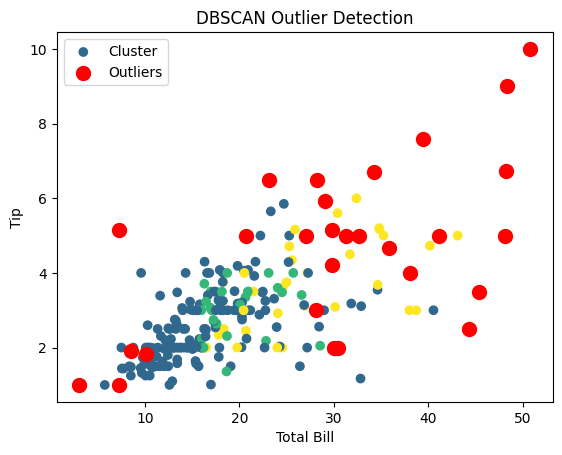

In [13]:
import matplotlib.pyplot as plt

# 전체 데이터
plt.scatter(df["total_bill"], df["tip"], c=df["Cluster"], label="Cluster")

# 이상치만 강조
outliers = df[df["Cluster"] == -1]
plt.scatter(outliers["total_bill"], outliers["tip"], 
            color="red", s=100, label="Outliers")

plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("DBSCAN Outlier Detection")
plt.legend()
plt.show()


In [14]:
from sklearn.cluster import DBSCAN

eps_values = [0.5, 0.8, 1.2]

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X_scaled)
    
    print(f"eps={eps}")
    print(pd.Series(labels).value_counts())
    print("-" * 30)

eps=0.5
 0    146
-1     56
 1     25
 2     17
Name: count, dtype: int64
------------------------------
eps=0.8
 0    154
 2     33
 1     29
-1     28
Name: count, dtype: int64
------------------------------
eps=1.2
 0    237
-1      7
Name: count, dtype: int64
------------------------------
